<a href="https://colab.research.google.com/github/AkashMaurya79/Dynamix-Networks/blob/Dynamix-Networks/SafeDrop_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Project Title:- SafeDrop Insights

In [ ]:
# Objective:- Analyzes delivery logs to identify "high-risk" drivers, optimize delivery windows, and visualize geospatialclusters where "fake" delivery attempts occur
#             most frequently.

In [ ]:
# Tasks:-
#     Task 1:- Data Preprocessing
#     Task 2:- Data Cleaning
#     Task 3:- Exploratory Data Analysis (EDA) with Engineering Feature
#     Task 4:- Geospatial Visualization
#     Task 5:- Executive Dashboard Link

In [ ]:
# Task 1:- Data Preprocessing

In [ ]:
# Import libriries:-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [ ]:
# I Analyze the Amazon dataset for that project and add the all required columns and features.

In [ ]:
path = kagglehub.dataset_download("sujalsuthar/amazon-delivery-dataset")
df=pd.read_csv(path+'/amazon_delivery.csv')

100%|██████████| 1.53M/1.53M [00:00<00:00, 2.73MB/s]

Extracting files...


In [ ]:
df

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen


In [ ]:
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [ ]:
df.tail()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen
43738,nsyz997960170,23,4.9,23.351058,85.325731,23.431058,85.405731,2022-03-02,17:10:00,17:15:00,Fog,Medium,scooter,Metropolitian,180,Cosmetics


In [ ]:
df.shape

(43739, 16)

In [ ]:
df.columns

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [ ]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [ ]:
# Observation of Task 1:-
#   In this dataset have 16 columns and 43739 rows with effective data.
#   The dataset have effective columns such as 'delivery_time','Store_Latitude','Store_Longitude', 'Drop_Latitude', 'Drop_Longitude' and so on.
#   The dataset have 2 integer, 5 float and rest of the columns object datatype.
#   In this dataset ,I observe that the delivery agent age and I found that the minimum age is 15 and the maximum age is 50. And also observe the mean of delivery time
#   and found that 124.905645 is the mean of delivery time.

In [ ]:
# Task 2:- Data Cleaning

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Agent_Age,0
Agent_Rating,54
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [ ]:
df['Agent_Rating'] = df['Agent_Rating'].fillna(df['Agent_Rating'].mean())

In [ ]:
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Agent_Age,0
Agent_Rating,0
Store_Latitude,0
Store_Longitude,0
Drop_Latitude,0
Drop_Longitude,0
Order_Date,0
Order_Time,0
Pickup_Time,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Observation of Task 2:-
#   In this datset , 2 columns have NULL values that are Agent_Rating and weather.
#   I fill that NULL values with the help of mean and mod.
#   This dataset don't have Duplicate values.

In [ ]:
 # Task 3:- Exploratory Data Analysis (EDA) with Engineering Feature

In [ ]:
from geopy.distance import geodesic
# Function to calculate distance-
def calculate_distance(row):
    target = (row['Drop_Latitude'], row['Drop_Longitude'])
    actual = (row['Store_Latitude'], row['Store_Longitude'])
    return geodesic(target, actual).meters
# Create Distance_Gap column-
df['Distance_Gap'] = df.apply(calculate_distance, axis=1)
# Check the dataset-
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance_Gap
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3020.736643
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20143.736910
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1549.692932
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7774.496620
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6197.897917


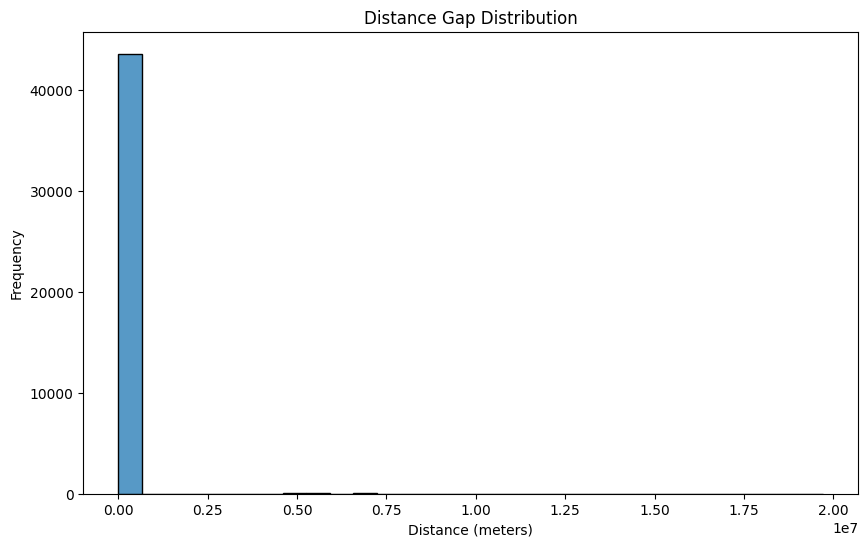

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Distance_Gap'], bins=30)
plt.title("Distance Gap Distribution")
plt.xlabel("Distance (meters)")
plt.ylabel("Frequency")
plt.show()

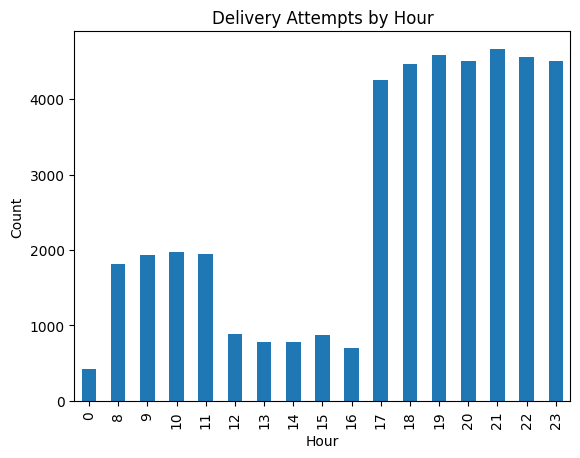

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Order_Date'] + ' ' + df['Order_Time'], errors='coerce')
df.dropna(subset=['Timestamp'], inplace=True)
df['Hour'] = df['Timestamp'].dt.hour
df.groupby('Hour')['Order_ID'].count().plot(kind='bar')
plt.title("Delivery Attempts by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

In [ ]:
# Check that timestamp and hour columns add in this dataset-
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance_Gap,Timestamp,Hour
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3020.736643,2022-03-19 11:30:00,11
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20143.736910,2022-03-25 19:45:00,19
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1549.692932,2022-03-19 08:30:00,8
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7774.496620,2022-04-05 18:00:00,18
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6197.897917,2022-03-26 13:30:00,13


In [ ]:
driver_performance = df.groupby("Agent_Age")["Delivery_Time"].mean()
driver_performance.sort_values()

,Delivery_Time
Agent_Age,
25,108.460442
29,108.594706
27,108.623256
22,108.717668
20,108.771536
24,108.994570
26,109.375174
21,109.409196
28,110.819642


/tmp/ipykernel_416/1710864509.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=driver_performance.index, y=driver_performance.values, palette='viridis')


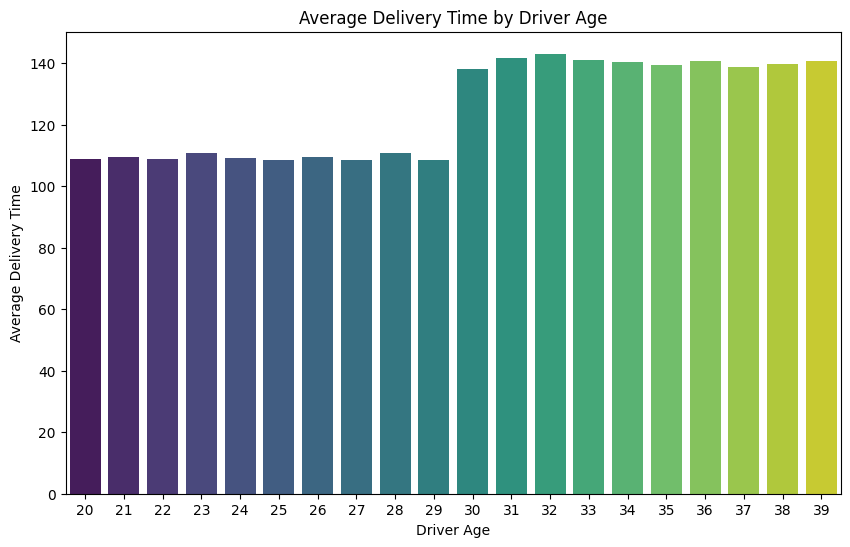

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=driver_performance.index, y=driver_performance.values, palette='viridis')
plt.title("Average Delivery Time by Driver Age")
plt.xlabel("Driver Age")
plt.ylabel("Average Delivery Time")
plt.show()

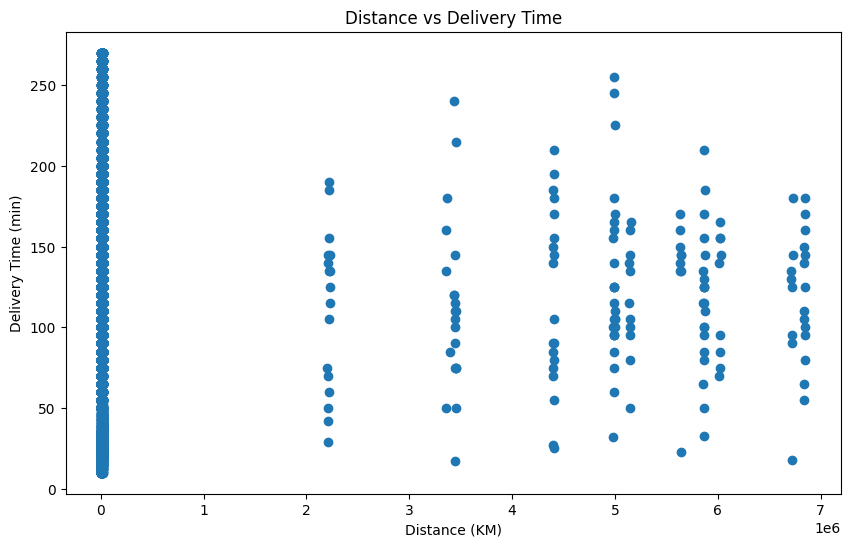

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Distance_Gap"], df["Delivery_Time"])
plt.xlabel("Distance (KM)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Delivery Time")
plt.show()

/tmp/ipykernel_416/1186796050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Weather", data=df, palette='viridis')


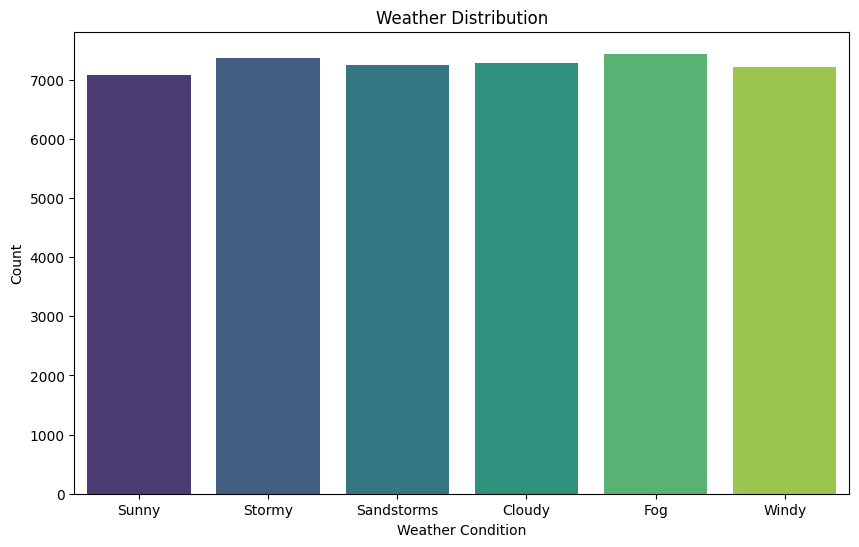

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Weather", data=df, palette='viridis')
plt.title("Weather Distribution")
plt.xlabel("Weather Condition")
plt.ylabel("Count")
plt.show()

In [ ]:
# Observation of Task 3:-
#   Firstly in this dataset I calculate the Distance_Gap column for all the rows and shows the distance between the actual delivery location and the target location &
#   show the distribution of distance_gap with the help of histogram.
#   Then I calculate the Timestamp and Hour columns for all the rows and show the Delivery attempt by hour.
#   And also I observe the delivery performance(Average Delivery Time by driver age) according to their age.
#   And I observe the scatter plot of distance VS delivery time.
#   And at the last but not the least I observe the weather distribution and found that all the weather have 7000 plus count.

In [ ]:
# Task 4:- Geospatial Visualization

In [ ]:
# For Geospatial map visulization-
import folium
map = folium.Map(location=[20.59,78.96], zoom_start=5)
for i,row in df.sample(500).iterrows():
    folium.CircleMarker(
        location=[row["Drop_Latitude"],row["Drop_Longitude"]],
        radius=3
    ).add_to(map)
# Print the map-
map

In [ ]:
driver_score = df.groupby("Agent_Age").agg({"Delivery_Time":"mean","Agent_Rating":"mean"})
driver_score["Integrity_Score"] = driver_score["Agent_Rating"]/driver_score["Delivery_Time"]
driver_score.sort_values("Integrity_Score",ascending=False)

,Delivery_Time,Agent_Rating,Integrity_Score
Agent_Age,,,
25,108.460442,4.672340,0.043079
20,108.771536,4.682758,0.043051
27,108.623256,4.674992,0.043039
29,108.594706,4.671535,0.043018
22,108.717668,4.673452,0.042987
24,108.994570,4.674797,0.042890
21,109.409196,4.683063,0.042803
26,109.375174,4.676178,0.042754
28,110.819642,4.685774,0.042283


In [ ]:
# Observation of Task 4:-
# In this task I observe the Geospatial map for drop langitude and drop latitude and its visulization.
# And secondly I observe the driver_score with Delivery_Time, Agent_Rating	& Integrity_Score.

In [ ]:
# Download the Updated Dataset for create the dashbord:-
df.to_csv("updated_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("updated_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Task 5:- Executive Dashboard Link

In [ ]:
# Tableau Dashboard Link:-
#    https://public.tableau.com/shared/7F2K9BDFY?:display_count=n&:origin=viz_share_link